# 03 — The AI Agent Market

## Question

How broad is the observed AI agent market in the Harpd discovery index, where were
those products observed, and how much of the slice reaches the rank board?


## Dataset

| Item | Value |
|---|---|
| File | `data/research/ai-agent-index.json` |
| Records | 334 |
| Slice definition | `category == ['agents']` (from the dataset's own `meta`) |
| Raw base | `https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/` |
| Licence | CC BY 4.0 |

The dataset's own disclosure states: *"Coverage view sliced from the Harpd Product
Discovery Index by product category. Not a ranking."* This notebook treats it
strictly as coverage.

**Domain caveat.** Rank Points are promotional placement bought with Credits — NOT
an editorial quality score.


## Method

1. Load the agent index slice.
2. `analysis.discovery_coverage` reports record count, distinct domains,
   rank-board coverage and the confidence distribution.
3. `analysis.discovery_sources` counts records per discovery source.
4. Tabulate `category_confidence` as a full value-count distribution, so a
   low-confidence classifier is visible rather than averaged away.
5. Derive the domain suffix distribution as a descriptive coverage signal.


## Analysis

In [1]:
import os
import sys
from pathlib import Path

# Make the repository root importable no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "harpd_research").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from harpd_research import analysis, loader

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print("repo root :", ROOT)
print("data base :", loader.resolved_data_base())
print("pandas    :", pd.__version__)
print()
print("DOMAIN CAVEAT")
print(analysis.PLACEMENT_CAVEAT)


repo root : /Users/shankou/harpd/harpd-ai-research-notebooks
data base : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/
pandas    : 3.0.5

DOMAIN CAVEAT
Rank Points are promotional placement bought with Credits — NOT an editorial quality score. Any ordering below is a promotional placement ordering, not a ranking of product quality.


In [2]:
agents = loader.load_agent = loader.load_ai_agent_index()

print("records     :", len(agents))
print("generatedAt :", agents.attrs.get("generatedAt"))
print("datasetId   :", agents.attrs.get("datasetId"))
print("slice       :", agents.attrs.get("sliceDefinition"))
print("disclosure  :", agents.attrs.get("disclosure"))
print()
print("columns:", list(agents.columns))

records     : 334
generatedAt : 2026-09-09T06:33:49.935Z
datasetId   : ai-agent-index
slice       : {'category': ['agents']}
disclosure  : Coverage view sliced from the Harpd Product Discovery Index by product category. Not a ranking.

columns: ['id', 'name', 'domain', 'url', 'category', 'category_confidence', 'title', 'description', 'discovered_from', 'observed_at', 'on_rank_board', 'profile_url']


In [3]:
coverage = analysis.discovery_coverage(agents, "AI agent index")
display(pd.DataFrame([coverage]).T.rename(columns={0: "value"}))

,value
label,AI agent index
records,334
distinctDomains,334
onRankBoard,0
onRankBoardPct,0.0
meanCategoryConfidence,0.8154
distinctDiscoverySources,11
observedAtMin,2026-09-09T05:32:39.445000+00:00
observedAtMax,2026-09-09T05:58:27.151000+00:00
hasData,True


In [4]:
sources = analysis.discovery_sources(agents, top_n=10)
print(f"{coverage['distinctDiscoverySources']} distinct discovery sources")
display(sources)

11 distinct discovery sources


,discovered_from,recordCount,sharePct
0,uneed.best,267,79.94
1,outbid.lol,25,7.49
2,appsumo.com,14,4.19
3,whatlaunched.today,11,3.29
4,biddirectory.lol,4,1.20
5,vibewar.lol,4,1.20
6,toolify.ai,4,1.20
7,claimrank.lol,2,0.60
8,dontbid.lol,1,0.30
9,growu.lol,1,0.30


In [5]:
confidence = (
    agents["category_confidence"].value_counts()
    .rename_axis("category_confidence").reset_index(name="records")
    .sort_values("category_confidence").reset_index(drop=True)
)
confidence["sharePct"] = (confidence["records"] / len(agents) * 100).round(2)
display(confidence)

print(f"mean confidence : {agents['category_confidence'].mean():.4f}")
print(f"median          : {agents['category_confidence'].median():.2f}")
print(f"at 1.0          : {int((agents['category_confidence'] >= 1.0).sum()):,} records")
print(f"at or below 0.5 : {int((agents['category_confidence'] <= 0.5).sum()):,} records")

,category_confidence,records,sharePct
0,0.17,4,1.20
1,0.50,116,34.73
2,0.67,1,0.30
3,1.00,213,63.77


mean confidence : 0.8154
median          : 1.00
at 1.0          : 213 records
at or below 0.5 : 120 records


In [6]:
# Domain suffix distribution - a descriptive coverage signal only.
suffix = (
    agents["domain"].dropna().astype(str)
    .str.rsplit(".", n=1).str[-1].str.lower()
    .value_counts().rename_axis("suffix").reset_index(name="records")
)
suffix["sharePct"] = (suffix["records"] / len(agents) * 100).round(2)
display(suffix.head(10))

print("distinct domains:", agents['domain'].nunique(), "of", len(agents), "records")
print("duplicate domains:", int(agents['domain'].duplicated().sum()))

,suffix,records,sharePct
0,com,133,39.82
1,ai,79,23.65
2,dev,21,6.29
3,io,19,5.69
4,co,10,2.99
5,app,9,2.69
6,sh,7,2.10
7,so,6,1.80
8,tech,4,1.20
9,xyz,4,1.20


distinct domains: 334 of 334 records
duplicate domains: 0


In [7]:
# Rank-board reachability, and whether the slice can be joined to profiles.
on_board = int(agents["on_rank_board"].astype(bool).sum()) if "on_rank_board" in agents else 0
empty_profile = int(agents["profile_url"].fillna("").astype(str).str.strip().eq("").sum())
empty_desc = int(agents["description"].fillna("").astype(str).str.strip().eq("").sum())

print(f"on rank board            : {on_board:,} of {len(agents):,} ({on_board/len(agents)*100:.2f}%)")
print(f"empty profile_url        : {empty_profile:,} of {len(agents):,}")
print(f"empty description        : {empty_desc:,} of {len(agents):,}")
print()
print("Observation window:", agents['observed_at'].min(), "->", agents['observed_at'].max())

on rank board            : 0 of 334 (0.00%)
empty profile_url        : 334 of 334
empty description        : 1 of 334

Observation window: 2026-09-09T05:32:39.445Z -> 2026-09-09T05:58:27.151Z


## Visualization

Left: where the records were observed. Right: the automated category-confidence
distribution, which shows the classifier is not uniformly confident.


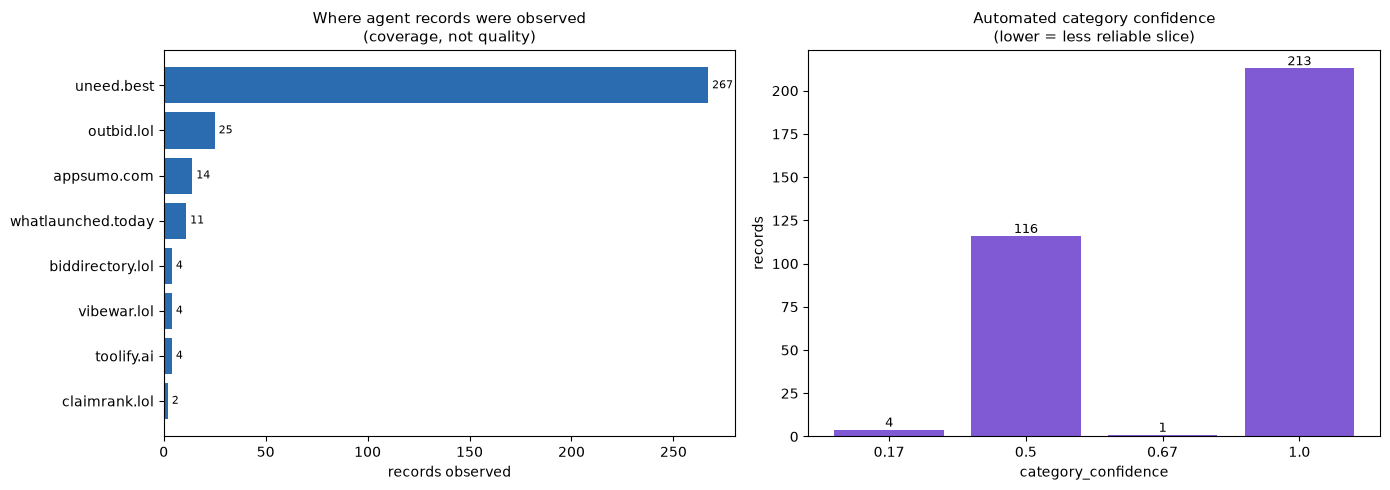

In [8]:
top_sources = sources.head(8).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_sources["discovered_from"], top_sources["recordCount"], color="#2b6cb0")
axes[0].set_xlabel("records observed")
axes[0].set_title("Where agent records were observed\n(coverage, not quality)", fontsize=11)
for y, v in enumerate(top_sources["recordCount"]):
    axes[0].text(v, y, f" {int(v)}", va="center", fontsize=8)

bars = axes[1].bar(confidence["category_confidence"].astype(str),
                   confidence["records"], color="#805ad5")
axes[1].set_xlabel("category_confidence")
axes[1].set_ylabel("records")
axes[1].set_title("Automated category confidence\n(lower = less reliable slice)", fontsize=11)
for bar, v in zip(bars, confidence["records"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{int(v)}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Findings

In [9]:
top_source = sources.iloc[0]
full_conf = int((agents["category_confidence"] >= 1.0).sum())
low_conf = int((agents["category_confidence"] <= 0.5).sum())

findings = [
    f"The AI agent index covers {coverage['records']:,} records across "
    f"{coverage['distinctDomains']:,} distinct domains.",

    f"{on_board:,} of {coverage['records']:,} records "
    f"({coverage['onRankBoardPct']}%) appear on the Harpd Rank board.",

    f"Records come from {coverage['distinctDiscoverySources']} distinct discovery "
    f"sources; the largest is '{top_source['discovered_from']}' with "
    f"{int(top_source['recordCount']):,} records ({top_source['sharePct']}% of the slice).",

    f"Automated category confidence is not uniform: {full_conf:,} records "
    f"({full_conf/coverage['records']*100:.2f}%) are assigned at 1.0, while "
    f"{low_conf:,} ({low_conf/coverage['records']*100:.2f}%) sit at 0.5 or below. "
    f"Mean confidence is {coverage['meanCategoryConfidence']}.",

    f"{empty_profile:,} of {coverage['records']:,} records have an empty "
    "`profile_url`, so this slice cannot be joined to catalog profiles on that field.",

    f"Observation window: {coverage['observedAtMin']} to {coverage['observedAtMax']}.",

    "The dataset's own disclosure states this is a coverage view, not a ranking, "
    "and this notebook respects that framing.",
]

for i, line in enumerate(findings, 1):
    print(f"{i}. {line}")

1. The AI agent index covers 334 records across 334 distinct domains.
2. 0 of 334 records (0.0%) appear on the Harpd Rank board.
3. Records come from 11 distinct discovery sources; the largest is 'uneed.best' with 267 records (79.94% of the slice).
4. Automated category confidence is not uniform: 213 records (63.77%) are assigned at 1.0, while 120 (35.93%) sit at 0.5 or below. Mean confidence is 0.8154.
5. 334 of 334 records have an empty `profile_url`, so this slice cannot be joined to catalog profiles on that field.
6. Observation window: 2026-09-09T05:32:39.445000+00:00 to 2026-09-09T05:58:27.151000+00:00.
7. The dataset's own disclosure states this is a coverage view, not a ranking, and this notebook respects that framing.


## Limitations

- **This is a coverage dataset, not a ranking.** It records which agent products
  were observed, not which are best or most used.
- Category assignment is automated and low-confidence for a large share of
  records. Category membership should be treated as indicative only.
- 334 records do not reach the rank board. That is expected — the discovery index
  is broader than the catalog — and is not evidence of product failure.
- No usage, revenue, download or traffic metric is present, and none is estimated.
- One observation window means no adoption trend can be measured. This notebook
  does not claim the market is growing or shrinking.
- Titles and descriptions are supplied by the discovered sites themselves and are
  not independently verified by Harpd.
- Discovery is not sampling. Records exist because a discovery source listed them,
  so the source mix shapes the slice far more than the underlying market does.


## Reproducibility

In [10]:
import platform
import sys

print("Reproduce this notebook")
print("=" * 60)
print("python :", sys.version.split()[0], "on", platform.platform())
print("pandas :", pd.__version__)
print("data   :", loader.resolved_data_base())
print()
print("From a clean machine:")
print("  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks")
print("  cd harpd-ai-research-notebooks")
print("  python -m venv .venv && . .venv/bin/activate")
print("  pip install -r requirements.txt")
print("  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>")
print()
print("Offline / pinned snapshot:")
print("  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...")


Reproduce this notebook
python : 3.13.12 on macOS-26.6.2-arm64-arm-64bit-Mach-O
pandas : 3.0.5
data   : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/

From a clean machine:
  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks
  cd harpd-ai-research-notebooks
  python -m venv .venv && . .venv/bin/activate
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>

Offline / pinned snapshot:
  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...


## Sources

- Dataset registry: <https://github.com/harpd-dev/harpd-ai-datasets>
- Canonical data home: <https://harpd.com/data/>
- Discovery surface (publisher): <https://harpd.com/discovery/>
- File: `data/research/ai-agent-index.json`
- Licence: CC BY 4.0

**Licence.** All Harpd dataset content is published under CC BY 4.0.

**Attribution.** Harpd (<https://harpd.com>).

**Not a source for.** Product quality, traffic, revenue, review scores or
market size. None of those are measured by these datasets, and none are
estimated in this notebook.
